# Per-Series Importance with Exogenous Features

This notebook demonstrates a powerful use case for per-series feature importance: **detecting heterogeneous effects of exogenous features across different time series**.

## The Problem

In multi-series forecasting, exogenous features (like temperature, promotions, or holidays) often have different effects on different series:
- Temperature might strongly affect ice cream sales in urban areas but not rural hardware stores
- Holiday flags might boost tourism in rural areas but have little effect on urban commuter shops

**Global feature importance analysis masks these heterogeneous effects**, showing only an "average" importance that may not reflect any individual series accurately.

## The Solution

Using `explain_per_series()`, we can compute feature importance separately for each series, revealing which exogenous features truly matter for each specific time series.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

from skforecast.recursive import ForecasterRecursiveMultiSeries

from xeries import (
    ConditionalPermutationImportance,
    SkforecastAdapter,
    plot_importance_bar,
    plot_importance_heatmap,
    plot_importance_per_series,
)

## 1. Generate Synthetic Data with Heterogeneous Exogenous Effects

We create 6 stores across 2 regions with **daily** sales data. The key insight is that **different exogenous features affect different regions**:

### Data Generation Logic

**Target Variable (Sales)**:
```
sales[t] = base_level + AR_effect + weekly_seasonality + trend + exogenous_effects + noise
```

Where:
- `base_level`: Different baseline for each store (100, 140, 180)
- `AR_effect`: 0.3 × sales[t-1] (autoregressive component)
- `weekly_seasonality`: 10 × sin(2π × t / 7) - captures weekly shopping patterns
- `trend`: Linear growth from 0 to 10 over the period
- `noise`: Random normal with σ=3

**Exogenous Feature Effects**:

| Feature | Formula | Urban Stores | Rural Stores |
|---------|---------|--------------|--------------|
| `temperature` | 15 + 12×sin(2π×t/365) + noise | **+0.8 × (temp - 15)** | 0 (no effect) |
| `holiday_flag` | ~15% of days randomly | 0 (no effect) | **+25 per holiday** |
| `promotion` | ~30% of days randomly | **+15 per promo day** | **+15 per promo day** |

This design ensures:
- **Urban stores**: Sales increase with warmer temperatures (e.g., ice cream, outdoor activities)
- **Rural stores**: Sales spike on holidays (e.g., tourism destinations, weekend getaways)
- **All stores**: Respond equally to promotions

Data shape: (10950, 7)
Series: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']

Region mapping:
  urban_001: urban
  urban_002: urban
  urban_003: urban
  rural_001: rural
  rural_002: rural
  rural_003: rural

Exogenous features: temperature, holiday_flag, promotion


,date,series_id,region,value,temperature,holiday_flag,promotion
0,2023-01-01,urban_001,urban,100.000000,16.490142,0.0,1.0
1,2023-01-02,urban_001,urban,88.983033,14.791767,0.0,0.0
2,2023-01-03,urban_001,urban,93.118064,17.356125,0.0,0.0
3,2023-01-04,urban_001,urban,101.499557,20.188526,0.0,1.0
4,2023-01-05,urban_001,urban,87.664604,15.123169,0.0,1.0
5,2023-01-06,urban_001,urban,66.691207,15.329167,1.0,0.0
6,2023-01-07,urban_001,urban,78.863466,20.974859,0.0,1.0
7,2023-01-08,urban_001,urban,78.113480,18.744801,1.0,0.0
8,2023-01-09,urban_001,urban,82.360198,15.238922,0.0,0.0
9,2023-01-10,urban_001,urban,90.163708,18.479386,0.0,0.0


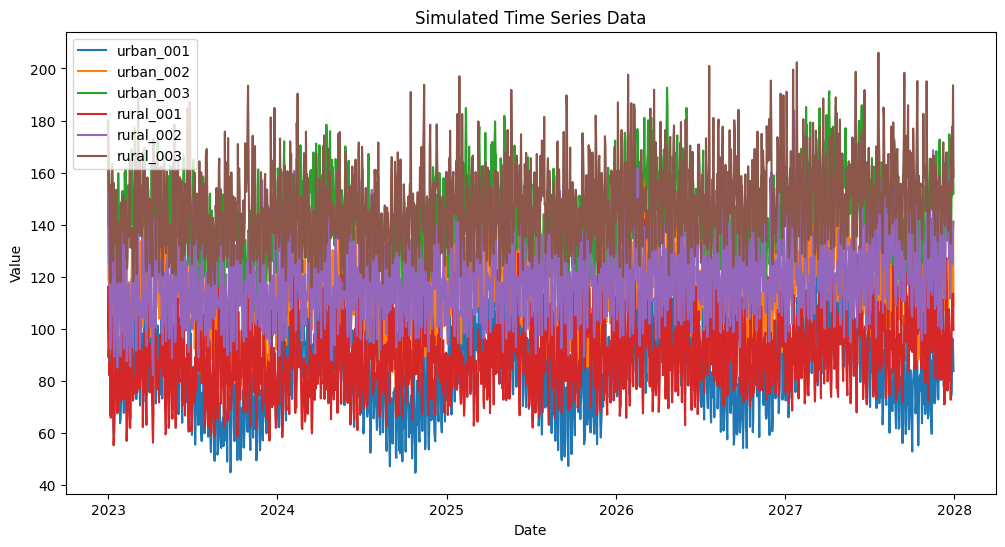

In [26]:
np.random.seed(42)

# =============================================================================
# Configuration
# =============================================================================
series_ids = ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']
regions = ['urban', 'urban', 'urban', 'rural', 'rural', 'rural']
n_days = 365 * 5  # Days per series (~5 years of daily data)

all_data = []

for i, (series_id, region) in enumerate(zip(series_ids, regions)):
    dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')
    
    # Seed each series differently for variation, but reproducibly
    np.random.seed(42 + i)
    
    # =========================================================================
    # EXOGENOUS FEATURES
    # =========================================================================
    
    # Temperature: yearly seasonal cycle centered at 15°C, amplitude ±12°C
    # Formula: temp = 15 + 12*sin(2π*t/365) + noise
    # This creates realistic seasonal variation (cold winters, warm summers)
    temperature = 15 + 12 * np.sin(2 * np.pi * np.arange(n_days) / 365) + np.random.normal(0, 3, n_days)
    
    # Holiday flag: ~15% of days are holidays (binary feature)
    holiday_flag = (np.random.random(n_days) > 0.85).astype(float)
    
    # Promotion: ~30% of days have promotions (binary feature)
    promotion = (np.random.random(n_days) > 0.7).astype(float)
    
    # =========================================================================
    # TARGET VARIABLE COMPONENTS
    # =========================================================================
    
    # Base level: varies by store (100, 140, 180) to simulate different store sizes
    base = 100 + (i % 3) * 40
    
    # Trend: gradual linear growth over time (0 to 10)
    trend = np.linspace(0, 10, n_days)
    
    # Weekly seasonality: 7-day cycle capturing weekly shopping patterns
    # Formula: 10*sin(2π*t/7) - peaks mid-week, dips on weekends (or vice versa)
    weekly_pattern = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    
    # Initialize sales values
    values = np.zeros(n_days)
    values[0] = base
    
    # =========================================================================
    # GENERATE SALES WITH HETEROGENEOUS EXOGENOUS EFFECTS
    # =========================================================================
    for t in range(1, n_days):
        # AR(1) component: sales depend on previous day (coefficient = 0.3)
        ar_effect = 0.3 * values[t-1]
        
        # -----------------------------------------------------------------
        # KEY: Exogenous effects differ by region!
        # -----------------------------------------------------------------
        if region == 'urban':
            # URBAN stores: temperature-sensitive (e.g., ice cream, outdoor goods)
            # Effect: +0.8 units per degree above 15°C (or -0.8 below)
            temp_effect = 0.8 * (temperature[t] - 15)
            holiday_effect = 0.0  # Holidays have NO effect on urban stores
        else:
            # RURAL stores: holiday-sensitive (e.g., tourism, weekend destinations)
            # Effect: +25 units on holiday days
            temp_effect = 0.0  # Temperature has NO effect on rural stores
            holiday_effect = 25.0 * holiday_flag[t]
        
        # Promotion effect: same for ALL stores (+15 units on promo days)
        promo_effect = 15.0 * promotion[t]
        
        # Combine all components into daily sales
        values[t] = (
            base * 0.5 +           # Baseline contribution
            ar_effect +            # Autoregressive (momentum)
            weekly_pattern[t] +    # Weekly seasonality
            trend[t] +             # Long-term trend
            temp_effect +          # Temperature effect (URBAN ONLY)
            holiday_effect +       # Holiday effect (RURAL ONLY)
            promo_effect +         # Promotion effect (ALL stores)
            np.random.normal(0, 3) # Random noise
        )
    
    # Store this series' data
    df = pd.DataFrame({
        'date': dates,
        'series_id': series_id,
        'region': region,
        'value': values,           # Target: daily sales
        'temperature': temperature, # Exog: affects URBAN only
        'holiday_flag': holiday_flag, # Exog: affects RURAL only
        'promotion': promotion      # Exog: affects ALL stores
    })
    all_data.append(df)

# Combine all series into one DataFrame
data = pd.concat(all_data, ignore_index=True)

print(f"Data shape: {data.shape}")
print(f"Series: {data['series_id'].unique().tolist()}")
print(f"\nRegion mapping:")
for s, r in zip(series_ids, regions):
    print(f"  {s}: {r}")
print(f"\nExogenous features: temperature, holiday_flag, promotion")
display(data.head(10))
#plotting the series
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id]
    plt.plot(subset['date'], subset['value'], label=series_id)
plt.title('Simulated Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

## 2. Prepare Multi-Series Inputs for skforecast

`skforecast` creates lagged features internally, so we prepare:
- `series_dict`: one target series per `series_id`
- `exog_dict`: aligned exogenous features per `series_id`

In [27]:
# Exogenous features used by skforecast
exog_features = ['temperature', 'holiday_flag', 'promotion']

# Build skforecast inputs as dictionaries keyed by series_id
series_dict = {}
exog_dict = {}

for sid in series_ids:
    subset = (
        data[data['series_id'] == sid]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
    )
    series_dict[sid] = subset['value'].rename(sid)
    exog_dict[sid] = subset[exog_features]

# Keep a simple mapping for readable output
series_mapping = {s: i for i, s in enumerate(series_ids)}
reverse_mapping = {v: k for k, v in series_mapping.items()}

print(f"Number of series: {len(series_dict)}")
print(f"Rows per series (example {series_ids[0]}): {len(series_dict[series_ids[0]])}")
print(f"Series index frequency: {series_dict[series_ids[0]].index.freq}")
print(f"Exogenous features: {exog_features}")
display(exog_dict[series_ids[0]].head())

Number of series: 6
Rows per series (example urban_001): 1825
Series index frequency: <Day>
Exogenous features: ['temperature', 'holiday_flag', 'promotion']


,temperature,holiday_flag,promotion
date,,,
2023-01-01,16.490142,0.0,1.0
2023-01-02,14.791767,0.0,0.0
2023-01-03,17.356125,0.0,0.0
2023-01-04,20.188526,0.0,1.0
2023-01-05,15.123169,0.0,1.0


## 3. Train a Global skforecast Model

In [28]:
# Configure and fit a global multi-series forecaster
estimator = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
 )

forecaster = ForecasterRecursiveMultiSeries(
    estimator=estimator,
    lags=3,
    encoding='ordinal',
)

forecaster.fit(series=series_dict, exog=exog_dict)

# Build the supervised matrix generated by skforecast
X_train_sk, y_train_sk = forecaster.create_train_X_y(
    series=series_dict,
    exog=exog_dict,
 )

# Identify the series identifier column in the generated design matrix
series_col = next(
    (c for c in X_train_sk.columns if 'level' in c.lower() or 'series' in c.lower()),
    None,
 )
if series_col is None:
    raise ValueError('Could not detect the series identifier column in X_train_sk.')

explain_features = [c for c in X_train_sk.columns if c != series_col]

print(f"Supervised matrix shape: {X_train_sk.shape}")
print(f"Target shape: {getattr(y_train_sk, 'shape', len(y_train_sk))}")
print(f"Series column for per-series explainability: {series_col}")
print(f"Number of explainable features: {len(explain_features)}")
display(X_train_sk.head())

Supervised matrix shape: (10932, 7)
Target shape: (10932,)
Series column for per-series explainability: _level_skforecast
Number of explainable features: 6


,lag_1,lag_2,lag_3,_level_skforecast,temperature,holiday_flag,promotion
date,,,,,,,
2023-01-04,93.118064,88.983033,100.000000,3,20.188526,0.0,1.0
2023-01-05,101.499557,93.118064,88.983033,3,15.123169,0.0,1.0
2023-01-06,87.664604,101.499557,93.118064,3,15.329167,1.0,0.0
2023-01-07,66.691207,87.664604,101.499557,3,20.974859,0.0,1.0
2023-01-08,78.863466,66.691207,87.664604,3,18.744801,1.0,0.0


## 4. Compute Global Feature Importance

We now compute conditional permutation importance on the supervised matrix generated by `skforecast`.
This keeps forecasting and explainability consistent with the same global model representation.

In [29]:
# Create xeries adapter for the trained skforecast model
adapter = SkforecastAdapter(
    forecaster=forecaster,
    series=series_dict,
    exog=exog_dict,
 )

explainer = ConditionalPermutationImportance(
    model=adapter,
    metric=mean_squared_error,
    n_repeats=5,
    random_state=42,
 )

# Global conditional permutation importance
global_result = explainer.explain(
    X=X_train_sk,
    y=y_train_sk,
    features=explain_features,
 )

importance_df = global_result.to_dataframe().sort_values('importance', ascending=False)

print('=== GLOBAL Conditional Feature Importance ===')
print('(Aggregated across all series in the skforecast design matrix)')
display(importance_df)

c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== GLOBAL Conditional Feature Importance ===
(Aggregated across all series in the skforecast design matrix)


,feature,importance,std
0,lag_1,145.652744,1.469636
5,promotion,97.061392,0.611030
4,holiday_flag,76.033081,1.482206
3,temperature,37.865282,0.621654
2,lag_3,16.304318,0.141343
1,lag_2,7.844689,0.207088


In [30]:
# Keep only exogenous features for a focused interpretation table
exog_importance_df = importance_df[importance_df['feature'].isin(exog_features)].copy()

print('=== GLOBAL Exogenous Feature Importance ===')
display(exog_importance_df.sort_values('importance', ascending=False))

=== GLOBAL Exogenous Feature Importance ===


,feature,importance,std
5,promotion,97.061392,0.611030
4,holiday_flag,76.033081,1.482206
3,temperature,37.865282,0.621654


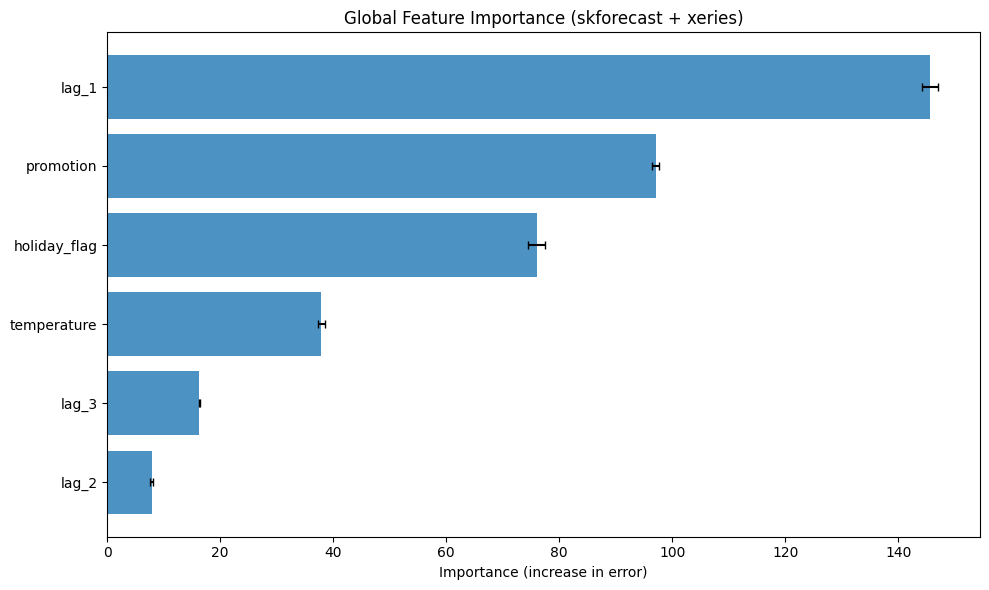

In [31]:
# Visualize global importance
fig, ax = plot_importance_bar(
    global_result,
    max_features=12,
    title='Global Feature Importance (skforecast + xeries)',
)
plt.show()

### Observation

The global importance shows moderate values for both `temperature` and `holiday_flag`. But this is misleading!
- `temperature` only affects urban stores
- `holiday_flag` only affects rural stores

The global view averages out these effects, hiding the true story.

## 5. Compute Per-Series Feature Importance

Now let's use `explain_per_series()` to reveal the **true heterogeneous effects**.

In [32]:
# Compute per-series importance using the detected series column
per_series_results_raw = explainer.explain_per_series(
    X=X_train_sk,
    y=y_train_sk,
    series_col=series_col,
    features=explain_features,
 )

# Normalize keys to readable series names.
# skforecast ordinal encoding is typically alphabetical by series name.
alphabetical_series_ids = sorted(series_ids)
per_series_results = {}

for key, value in per_series_results_raw.items():
    readable_key = None

    # Already a string label
    if key in series_ids:
        readable_key = key
    else:
        # Try integer-like code mapped to alphabetical order
        try:
            key_int = int(key)
            if 0 <= key_int < len(alphabetical_series_ids):
                readable_key = alphabetical_series_ids[key_int]
        except (TypeError, ValueError):
            readable_key = None

    if readable_key is None:
        readable_key = str(key)

    per_series_results[readable_key] = value

print(f"Computed importance for {len(per_series_results)} series")
print(f"Mapped series keys: {list(per_series_results.keys())}")

c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X 

Computed importance for 6 series
Mapped series keys: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']


c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X 

In [33]:
# Display results for each series
for series_id, result in per_series_results.items():
    region = 'URBAN' if 'urban' in series_id else 'RURAL'
    print(f"\n=== {series_id} ({region}) ===")
    df = result.to_dataframe()
    # Highlight exogenous features
    for _, row in df.iterrows():
        marker = " <-- EXOG" if row['feature'] in exog_features else ""
        print(f"  {row['feature']:15} {row['importance']:8.4f}{marker}")


=== urban_001 (URBAN) ===
  lag_1           205.6704
  promotion       100.9259 <-- EXOG
  temperature      73.2055 <-- EXOG
  lag_3            18.8958
  lag_2            12.4963
  holiday_flag      0.6729 <-- EXOG

=== urban_002 (URBAN) ===
  lag_1           216.4977
  promotion        97.0766 <-- EXOG
  temperature      73.2963 <-- EXOG
  lag_3            18.6209
  lag_2            14.5680
  holiday_flag      1.2670 <-- EXOG

=== urban_003 (URBAN) ===
  lag_1           195.3999
  promotion        98.0500 <-- EXOG
  temperature      87.2533 <-- EXOG
  lag_3            24.8864
  lag_2            13.3852
  holiday_flag      1.3354 <-- EXOG

=== rural_001 (RURAL) ===
  holiday_flag    154.4183 <-- EXOG
  lag_1           128.3628
  promotion        96.5942 <-- EXOG
  lag_3            20.9624
  lag_2             9.6748
  temperature       3.4467 <-- EXOG

=== rural_002 (RURAL) ===
  holiday_flag    151.4518 <-- EXOG
  lag_1           121.5257
  promotion        89.1098 <-- EXOG
  lag_3   

## 6. Visualize Per-Series Importance

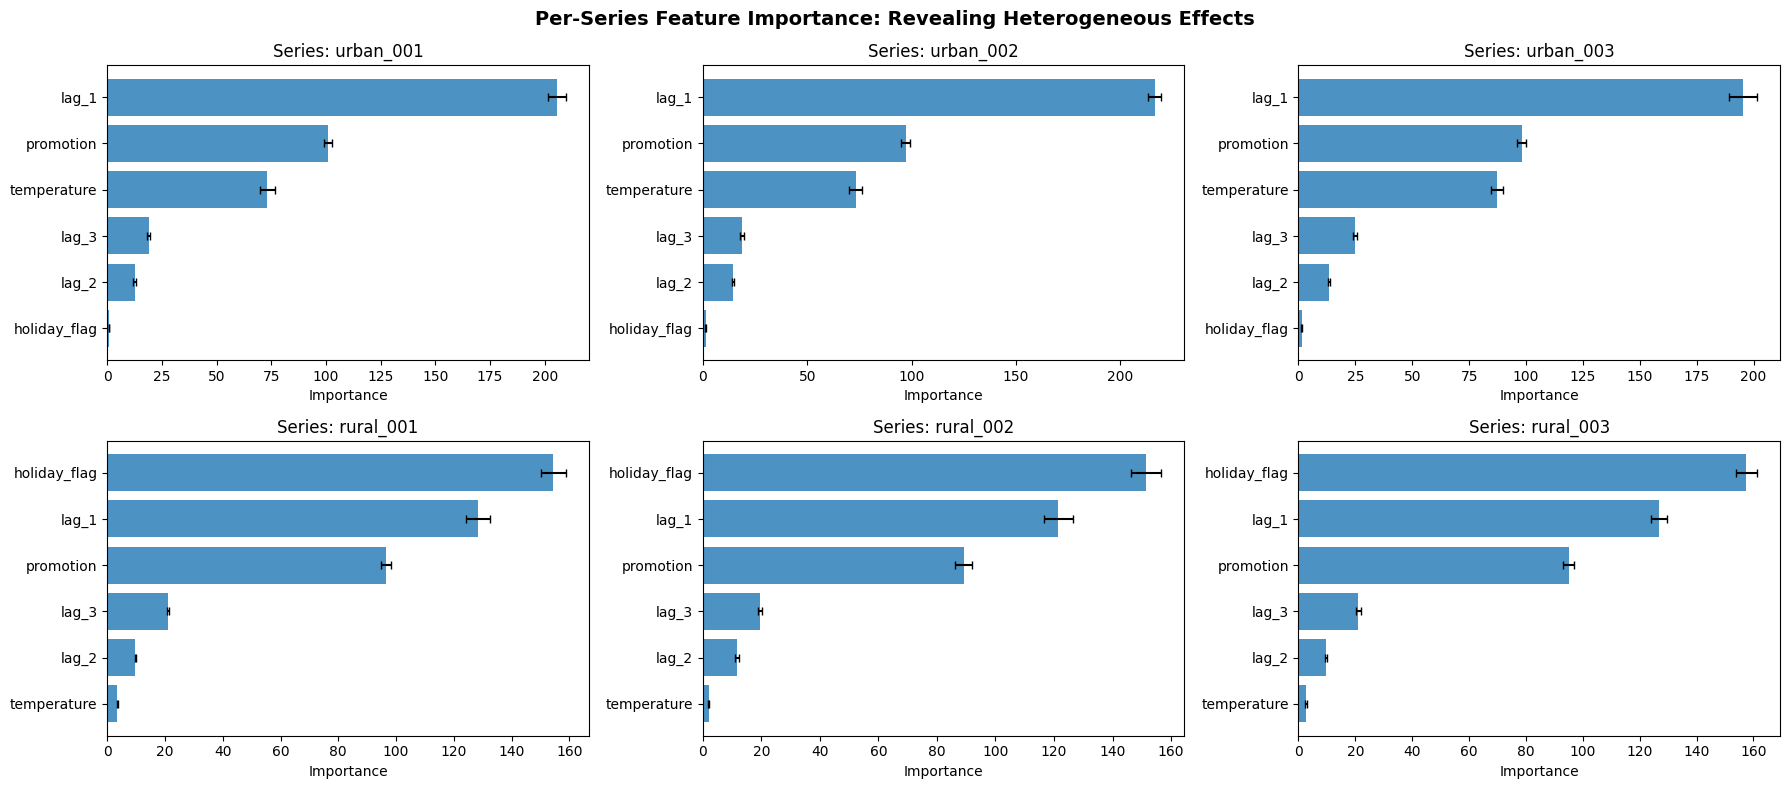

In [34]:
# Grid of bar charts for all series
fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=6,
    ncols=3,
    title="Per-Series Feature Importance: Revealing Heterogeneous Effects"
)
plt.show()

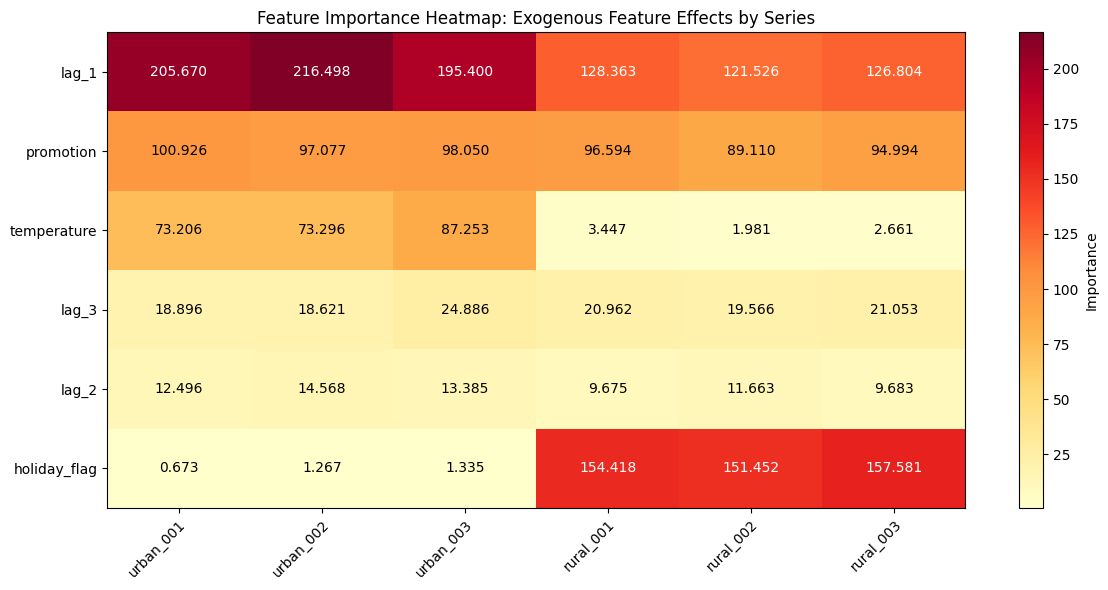

In [35]:
# Heatmap comparison across all series
fig, ax = plot_importance_heatmap(
    per_series_results,
    features=all_features,
    figsize=(12, 6),
    title="Feature Importance Heatmap: Exogenous Feature Effects by Series"
)
plt.show()

## 7. Compare Urban vs Rural Groups

Let's aggregate by region to clearly see the pattern.

In [36]:
# Separate results by region
urban_results = {k: v for k, v in per_series_results.items() if 'urban' in k}
rural_results = {k: v for k, v in per_series_results.items() if 'rural' in k}

# Aggregate importance by region
def aggregate_importance(results_dict):
    all_importances = {}
    for _, result in results_dict.items():
        for feat, imp in zip(result.feature_names, result.importances):
            all_importances.setdefault(feat, []).append(float(imp))
    return {feat: float(np.mean(vals)) for feat, vals in all_importances.items()}

urban_avg_all = aggregate_importance(urban_results)
rural_avg_all = aggregate_importance(rural_results)

# Focus comparison on exogenous features only
urban_avg = {f: urban_avg_all.get(f, 0.0) for f in exog_features}
rural_avg = {f: rural_avg_all.get(f, 0.0) for f in exog_features}
global_avg = {
    f: float(global_result.importances[global_result.feature_names.index(f)])
    for f in exog_features
    if f in global_result.feature_names
}

comparison_df = pd.DataFrame({
    'Feature': exog_features,
    'Urban (avg)': [urban_avg.get(f, 0.0) for f in exog_features],
    'Rural (avg)': [rural_avg.get(f, 0.0) for f in exog_features],
    'Global': [global_avg.get(f, 0.0) for f in exog_features],
}).set_index('Feature')

print('=== Exogenous Feature Importance Comparison ===')
print(comparison_df.round(4).to_string())

=== Exogenous Feature Importance Comparison ===
              Urban (avg)  Rural (avg)   Global
Feature                                        
temperature       77.9183       2.6961  37.8653
holiday_flag       1.0918     154.4838  76.0331
promotion         98.6842      93.5661  97.0614


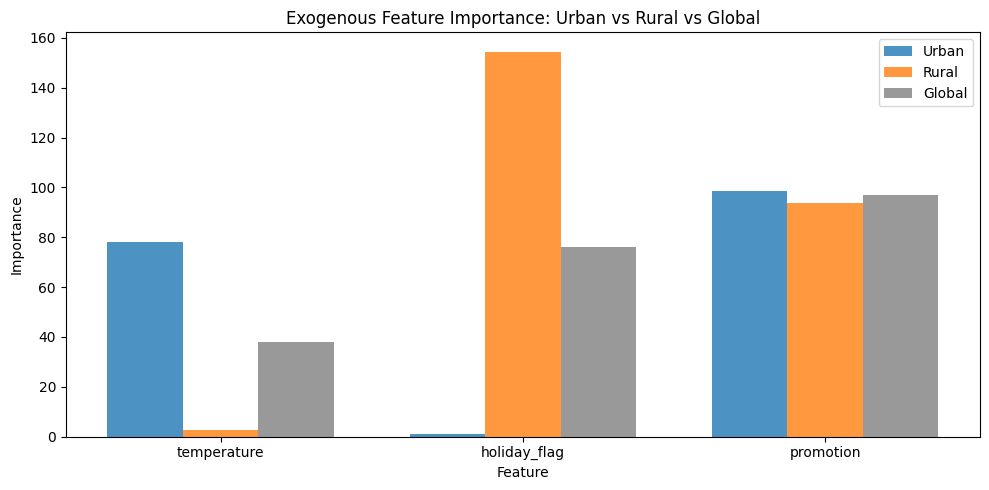

In [37]:
# Visualize exogenous feature comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(len(exog_features))
width = 0.25

ax.bar(x - width, comparison_df['Urban (avg)'], width, label='Urban', alpha=0.8)
ax.bar(x, comparison_df['Rural (avg)'], width, label='Rural', alpha=0.8)
ax.bar(x + width, comparison_df['Global'], width, label='Global', alpha=0.8, color='gray')

ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Exogenous Feature Importance: Urban vs Rural vs Global')
ax.set_xticks(x)
ax.set_xticklabels(exog_features)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Key Insights

### What Per-Series Analysis Reveals:

| Feature | True Effect | Global Importance | Per-Series Finding |
|---------|-------------|-------------------|--------------------|
| `temperature` | Urban only | Moderate | High for urban, ~0 for rural |
| `holiday_flag` | Rural only | Moderate | High for rural, ~0 for urban |
| `promotion` | All series | Moderate | Consistent across all series |

### Why This Matters:

1. **Better Feature Understanding**: Global importance would suggest both `temperature` and `holiday_flag` are moderately important everywhere. Per-series analysis reveals the true, actionable insight.

2. **Targeted Interventions**: If you're planning a marketing campaign:
   - For urban stores: Focus on temperature-based promotions (e.g., hot weather discounts)
   - For rural stores: Plan around holidays and tourism seasons

3. **Model Debugging**: If predictions are poor for specific series, per-series importance helps identify which features the model is (incorrectly) relying on.

4. **Feature Engineering**: Knowing that `temperature` only matters for urban stores, you might create interaction features like `temperature * is_urban`.

In [38]:
# Final summary table
print("\n" + "="*60)
print("SUMMARY: Heterogeneous Exogenous Feature Effects")
print("="*60)

def dominant_group(feature_name: str) -> str:
    u = urban_avg.get(feature_name, 0.0)
    r = rural_avg.get(feature_name, 0.0)
    if abs(u - r) < 1e-9:
        return "balanced"
    return "urban" if u > r else "rural"

print("\nTemperature Effect:")
print(f"  Urban stores:  {urban_avg.get('temperature', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('temperature', 0):.4f}")
print(f"  Dominant group: {dominant_group('temperature').upper()}")

print("\nHoliday Flag Effect:")
print(f"  Urban stores:  {urban_avg.get('holiday_flag', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('holiday_flag', 0):.4f}")
print(f"  Dominant group: {dominant_group('holiday_flag').upper()}")

print("\nPromotion Effect:")
print(f"  Urban stores:  {urban_avg.get('promotion', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('promotion', 0):.4f}")
print(f"  Dominant group: {dominant_group('promotion').upper()}")

print("\n" + "="*60)


SUMMARY: Heterogeneous Exogenous Feature Effects

Temperature Effect:
  Urban stores:  77.9183
  Rural stores:  2.6961
  Dominant group: URBAN

Holiday Flag Effect:
  Urban stores:  1.0918
  Rural stores:  154.4838
  Dominant group: RURAL

Promotion Effect:
  Urban stores:  98.6842
  Rural stores:  93.5661
  Dominant group: URBAN

